# Sentiment Analysis using SimpleRNN

## Import Modules

In [341]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense
from tensorflow.keras.utils import plot_model, pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer

# import train test split from sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
from random import shuffle

## Prepare Synthetic Data

In [342]:
positive = [
    "I love this movie", "This is amazing", "Great job well done", "What a pleasant day",
    "Happy with the result", "that was really good", "Absolutely loved the performance",
    "Superb work by the team", "Wonderful service and friendly staff", "The food tasted great",
    "Excellent experience overall today", "Proud of this achievement", "You did a fantastic job",
    "The design looks beautiful", "Everything worked perfectly fine", "Smooth process from start",
    "Clear instructions and easy setup", "Fast response great support", "Impressive speed and accuracy",
    "Love the clean interface", "The update improved performance", "Works exactly as expected",
    "Learned something new today", "Beautiful weather for a walk", "That solution was elegant",
    "Appreciate your quick help", "Setup was simple and quick", "Results look very promising",
    "This makes me happy", "The team delivered excellence", "Strong performance under pressure",
    "Great clarity in documentation", "Neat code and structure", "The app runs smoothly",
    "Kudos on the release", "Effective meeting and outcomes", "The demo went well",
    "Confident about the plan", "Positive feedback from users", "Glad we fixed it",
    "Nice UI and UX balance", "Tests passed with flying colors", "Robust and reliable system",
    "The model improved accuracy", "Clear win for the team", "Smart idea and execution",
    "The graphs look good", "Trained model converged quickly", "Predictive power looks strong",
    "Great value for money"
]

negative = [
    "I hate this thing", "This is terrible", "Really bad experience", "So disappointed today",
    "Not good at all", "The service was awful", "Very slow and buggy", "That update broke everything",
    "The results were worse", "Poor quality and support", "I regret this purchase", "The UI feels clunky",
    "Documentation is confusing", "Setup was painfully hard", "Unacceptable delay in response",
    "The app keeps crashing", "Totally not worth it", "Missed the deadline again", "The food tasted bland",
    "Customer service ignored me", "The plan failed badly", "Bugs everywhere very annoying",
    "Unexpected charges appeared today", "Wrong output for input", "Model overfitted the data",
    "Accuracy dropped after update", "Performance issues persist still", "The design looks messy",
    "The codebase is messy", "This took too long", "Terrible choice for beginners", "The product arrived damaged",
    "Support never replied back", "False positives are high", "False negatives are high", "The workshop was boring",
    "Bad idea causes problems", "Completely wasted my time", "The team missed expectations", "Poor planning and execution",
    "I am extremely frustrated", "Nothing worked as expected", "The interface is confusing", "The price is unreasonable",
    "Not satisfied with outcome", "The patch introduced regressions", "Data pipeline kept failing",
    "The meeting lacked focus", "Decision making was poor", "The colors hurt readability"
]

In [343]:
sentences = positive + negative
labels = ["positive"] * len(positive) + ["negative"] * len(negative)

paired = list(zip(sentences, labels))
shuffle(paired)
sentences, labels = zip(*paired)

len(sentences), len(labels)

(100, 100)

In [344]:
# Build DataFrame with 2 columns: sentence, sentiment
df = pd.DataFrame({
    "sentence": sentences,
    "sentiment": labels
})

## Tokenization

In [345]:
# oov mean out of vaocabulary token.
# If a token is found which is not in vocabulary, replace with <na>
t = Tokenizer(oov_token='<na>')

t.fit_on_texts(df['sentence'])

In [346]:
print(
    t.document_count, '\n', 
    t.num_words, '\n', 
    t.word_index, '\n',
    t.word_counts, "\n"
)

100 
 None 
 {'<na>': 1, 'the': 2, 'and': 3, 'this': 4, 'was': 5, 'is': 6, 'for': 7, 'great': 8, 'i': 9, 'performance': 10, 'team': 11, 'today': 12, 'looks': 13, 'model': 14, 'service': 15, 'setup': 16, 'poor': 17, 'good': 18, 'very': 19, 'not': 20, 'with': 21, 'accuracy': 22, 'a': 23, 'that': 24, 'update': 25, 'support': 26, 'it': 27, 'strong': 28, 'data': 29, 'clear': 30, 'look': 31, 'quick': 32, 'worked': 33, 'as': 34, 'expected': 35, 'well': 36, 'everything': 37, 'colors': 38, 'messy': 39, 'love': 40, 'interface': 41, 'me': 42, 'happy': 43, 'beautiful': 44, 'missed': 45, 'meeting': 46, 'in': 47, 'documentation': 48, 'from': 49, 'app': 50, 'really': 51, 'bad': 52, 'experience': 53, 'idea': 54, 'execution': 55, 'food': 56, 'tasted': 57, 'results': 58, 'confusing': 59, 'ui': 60, 'terrible': 61, 'job': 62, 'plan': 63, 'design': 64, 'improved': 65, 'response': 66, 'false': 67, 'are': 68, 'high': 69, 'glad': 70, 'we': 71, 'fixed': 72, 'hate': 73, 'thing': 74, 'predictive': 75, 'power': 7

## Generate Numeric Sequence from Tokens

In [347]:
# Numerical encode the docs, replace word with it's index
sequence = t.texts_to_sequences(df['sentence'])
sequence

[[70, 71, 72, 27],
 [9, 73, 4, 74],
 [75, 76, 13, 28],
 [14, 77, 2, 29],
 [2, 15, 5, 78],
 [4, 79, 80, 81],
 [30, 82, 3, 83, 16],
 [84, 85, 5, 17],
 [2, 86, 31, 18],
 [87, 88, 32, 89],
 [90, 33, 34, 35],
 [2, 91, 92, 36],
 [37, 33, 93, 94],
 [95, 96, 19, 97],
 [98, 3, 99, 100],
 [101, 20, 102, 27],
 [103, 104, 7, 105],
 [106, 107, 21, 108, 38],
 [2, 109, 6, 39],
 [10, 110, 111, 112],
 [113, 14, 114, 115],
 [40, 2, 116, 41],
 [117, 118, 4, 119],
 [4, 120, 42, 43],
 [121, 122, 3, 22],
 [44, 123, 7, 23, 124],
 [2, 11, 45, 125],
 [126, 46, 3, 127],
 [128, 23, 129, 130],
 [131, 15, 132, 42],
 [133, 134, 3, 135],
 [2, 136, 5, 137],
 [138, 139, 12],
 [8, 140, 47, 48],
 [24, 25, 141, 37],
 [142, 143, 49, 144],
 [22, 145, 146, 25],
 [20, 18, 147, 148],
 [2, 11, 149, 150],
 [8, 151, 7, 152],
 [4, 6, 153],
 [2, 50, 154, 155],
 [29, 156, 157, 158],
 [28, 10, 159, 160],
 [51, 52, 53],
 [161, 54, 3, 55],
 [17, 162, 3, 55],
 [17, 163, 3, 26],
 [43, 21, 2, 164],
 [24, 5, 51, 18],
 [2, 56, 57, 8],
 [9,

## Make all sentences equal size using Paddings

In [348]:
max_len = 10
X = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')

In [349]:
lbl_enc = LabelEncoder()
y = lbl_enc.fit_transform(df["sentiment"]).astype('float32').reshape(-1, 1)

y

array([[1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],

## Train Test Split our Small Data

In [350]:
X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, df['sentence'].to_numpy(), test_size=0.2, stratify=y
)

X_train, y_train, s_train

(array([[ 22, 145, 146,  25,   0,   0,   0,   0,   0,   0],
        [128,  23, 129, 130,   0,   0,   0,   0,   0,   0],
        [ 37,  33,  93,  94,   0,   0,   0,   0,   0,   0],
        [226, 227, 228,  12,   0,   0,   0,   0,   0,   0],
        [  9,  40,   4, 225,   0,   0,   0,   0,   0,   0],
        [133, 134,   3, 135,   0,   0,   0,   0,   0,   0],
        [220, 221,   2,  10,   0,   0,   0,   0,   0,   0],
        [ 87,  88,  32,  89,   0,   0,   0,   0,   0,   0],
        [ 30,  82,   3,  83,  16,   0,   0,   0,   0,   0],
        [ 44, 123,   7,  23, 124,   0,   0,   0,   0,   0],
        [  4, 120,  42,  43,   0,   0,   0,   0,   0,   0],
        [  2,  91,  92,  36,   0,   0,   0,   0,   0,   0],
        [ 24, 198,   5, 199,   0,   0,   0,   0,   0,   0],
        [ 17, 163,   3,  26,   0,   0,   0,   0,   0,   0],
        [ 24,   5,  51,  18,   0,   0,   0,   0,   0,   0],
        [ 40,   2, 116,  41,   0,   0,   0,   0,   0,   0],
        [200, 201,   2, 202,   0,   0,  

In [351]:
X_test, y_test, s_test

(array([[  8,  62,  36, 175,   0,   0,   0,   0,   0,   0],
        [  2,  50, 154, 155,   0,   0,   0,   0,   0,   0],
        [ 16,   5, 222, 223,   0,   0,   0,   0,   0,   0],
        [106, 107,  21, 108,  38,   0,   0,   0,   0,   0],
        [  2,  86,  31,  18,   0,   0,   0,   0,   0,   0],
        [232, 233,  49, 234,   0,   0,   0,   0,   0,   0],
        [ 75,  76,  13,  28,   0,   0,   0,   0,   0,   0],
        [  2, 250,   6, 251,   0,   0,   0,   0,   0,   0],
        [237, 238,   2,  63,   0,   0,   0,   0,   0,   0],
        [ 29, 156, 157, 158,   0,   0,   0,   0,   0,   0],
        [ 45,   2, 229, 230,   0,   0,   0,   0,   0,   0],
        [  2,  64,  13,  39,   0,   0,   0,   0,   0,   0],
        [ 61, 171,   7, 172,   0,   0,   0,   0,   0,   0],
        [  2,  11, 149, 150,   0,   0,   0,   0,   0,   0],
        [ 17, 162,   3,  55,   0,   0,   0,   0,   0,   0],
        [  2,  11,  45, 125,   0,   0,   0,   0,   0,   0],
        [  8, 151,   7, 152,   0,   0,  

## Build the RNN Model

In [352]:
model = Sequential()
# Timestamp 4, input shape 1. Model will rollout 4 times processing 1 word at a time
model.add(Input(shape=(max_len,1))) 
# Add a simple RNN with 3 units, we don't see the outputs for each timestamp
model.add(SimpleRNN(24, activation='tanh', return_sequences=False)) 
model.add(Dense(1, activation="sigmoid"))

model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_17 (SimpleRNN)       │ (None, 24)             │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

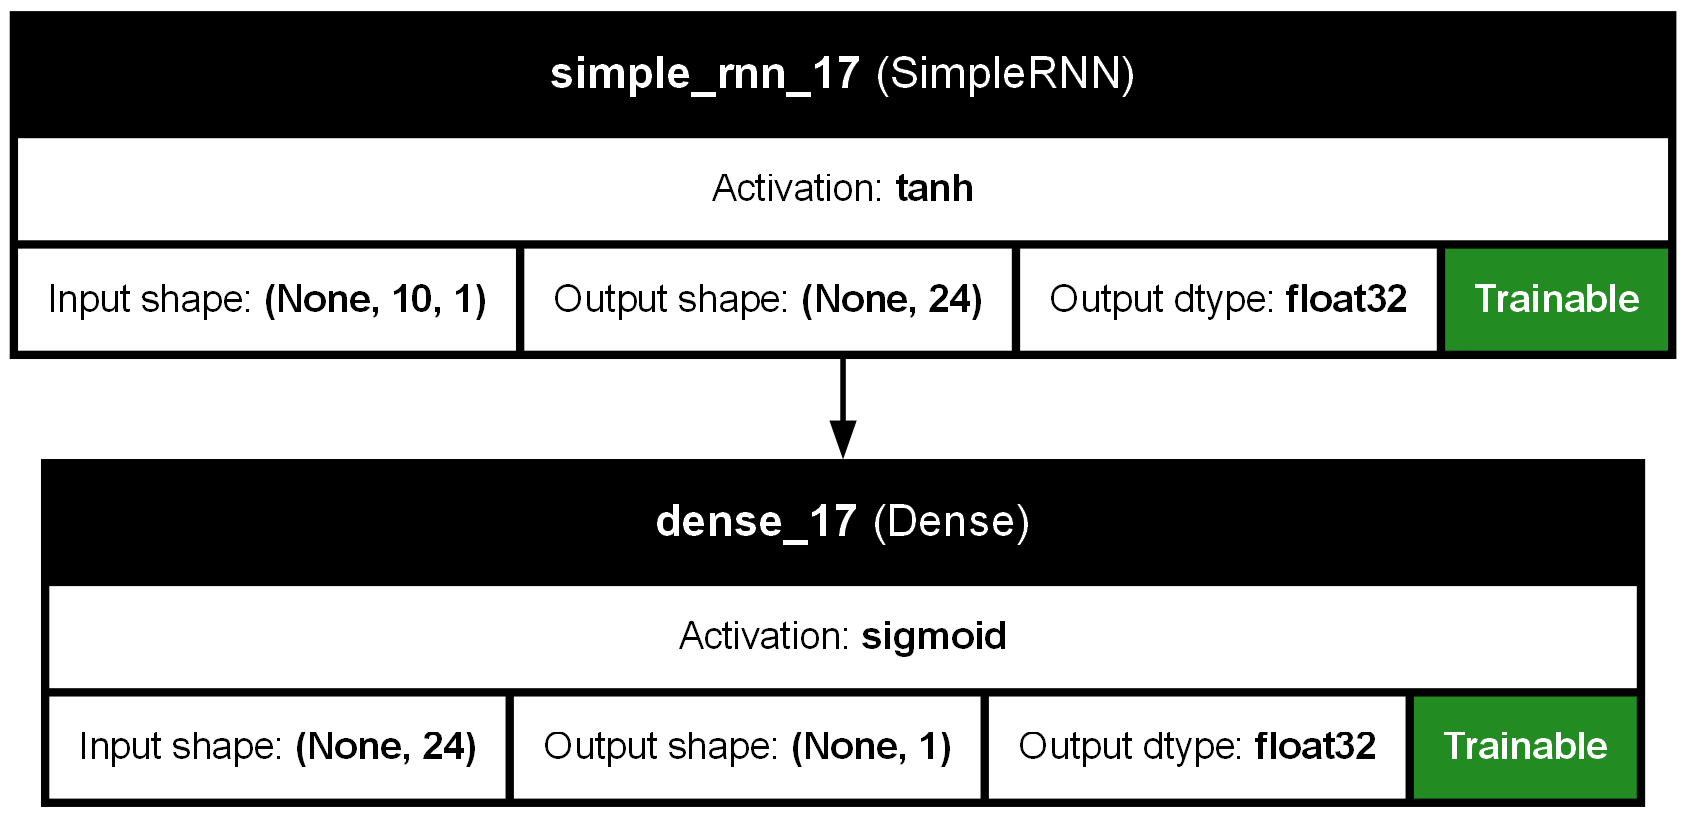

In [353]:
plot_model(
    model, 
    show_shapes=True,
    show_dtype=True,
    show_layer_activations=True,
    show_layer_names=True,
    show_trainable=True
)

## Compile and Train the Model

In [354]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [355]:
es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1)

In [356]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    batch_size=1,
    callbacks=[es],
    verbose=1
)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5500 - loss: 0.6957 - val_accuracy: 0.5500 - val_loss: 0.6873
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5250 - loss: 0.6521 - val_accuracy: 0.5500 - val_loss: 0.6856
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6000 - loss: 0.6453 - val_accuracy: 0.5500 - val_loss: 0.6830
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5375 - loss: 0.6310 - val_accuracy: 0.5500 - val_loss: 0.6809
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6375 - loss: 0.6266 - val_accuracy: 0.5000 - val_loss: 0.6785
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5875 - loss: 0.6167 - val_accuracy: 0.6000 - val_loss: 0.6832
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6375 - loss: 0.6150 - val_accuracy: 0.6500 - val_loss: 0.6805
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5875 - loss: 0.6084 - val_accuracy: 0.6500 - val_loss:

## Make Predictions

In [357]:
predictions = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


In [358]:
# predictions -> probabilities of "positive"
probs = np.asarray(predictions).ravel()
pred_lbls = (probs >= 0.5).astype(int)

# y_test flatten to ints
true_lbls = np.asarray(y_test).ravel().astype(int)

# decode 0/1 back to string labels using fitted LabelEncoder
true_sentiments = lbl_enc.inverse_transform(true_lbls)
pred_sentiments = lbl_enc.inverse_transform(pred_lbls)

# Build and print table
df_out = pd.DataFrame({
    "Original Sentence": s_test,            # from your split
    "Y (True)": true_sentiments,
    "Y (Predicted)": pred_sentiments,
    "Predicted Probability": probs.round(3)
})

df_out.head(20)

,Original Sentence,Y (True),Y (Predicted),Predicted Probability
0,Great job well done,positive,positive,0.516
1,The app runs smoothly,positive,positive,0.516
2,Setup was painfully hard,negative,positive,0.516
3,Tests passed with flying colors,positive,positive,0.882
4,The graphs look good,positive,positive,0.594
5,Positive feedback from users,positive,positive,0.516
6,Predictive power looks strong,positive,positive,0.557
7,The price is unreasonable,negative,positive,0.516
8,Confident about the plan,positive,positive,0.518
9,Data pipeline kept failing,negative,positive,0.516


In [363]:
evaluate_text = input('Insert a sentence, first 10 words would be considered')
eval_seq = t.texts_to_sequences([evaluate_text])
eval_padded = pad_sequences(eval_seq, maxlen=max_len, padding='post', truncating='post')
pred = model.predict(eval_padded)
p = float(pred.ravel()[0])             # scalar prob for 'positive'
res = 'Positive' if p >= 0.5 else 'Negative'
print(f"Sentence: {evaluate_text} -> {res} (p={p:.3f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Sentence: It was pleasure meeting you -> Positive (p=0.883)
